In [1]:
import numpy as np
from pathlib import Path
from define_data_and_variables import HMCConfig, Data, hmc_config, data, c_data, dict_to_struct, make_dumpable, hash_configs, name_map
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import os

{'N': 50, 'nc14': 2, 'nd18o': 194, 'nd18or': 10001, 'H': 1000, 'dc': 20.0, 'pm': 1.71472, 'ps': 0.7107, 'th': np.float64(1999.0), 'cs': array([   0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,
        180.,  200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,
        360.,  380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,
        540.,  560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,
        720.,  740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,
        900.,  920.,  940.,  960.,  980., 1000.]), 'c14': array([-1198., -5284.]), 'c14d': array([420., 850.]), 'c14s': array([ 6., 35.]), 'ic14v': array([0.02777778, 0.00081633]), 'd18o': array([52.8, 52. , 51.7, 53.1, 54.1, 53. , 52.9, 52.1, 49.6, 46.7, 45.8,
       46.2, 46.1, 46.1, 46.7, 47.7, 49.1, 50.5, 52.1, 55. , 54.2, 53. ,
       53.7, 54.4, 53.5, 52.4, 52.2, 51.5, 51.3, 50.8, 51.2, 51.4, 51.6,
       51.5, 51.2, 50.4, 50.8, 51.3, 53.2, 54.3, 54.5, 54.8, 54.6, 51.8,
       49.7, 48.9, 49.8, 50.4, 49

In [2]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out

def get_index(N, cs, depths, depth_index):
    low, high = 0, N
    target = depths[depth_index]
    print(target)
    
    while low < high:
        mid = int(low + (high - low) / 2)
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid
    
    return low

In [3]:
base_dir = Path.cwd()
np.random.seed(hmc_config["sd"])
sp = np.random.multivariate_normal(data["pm"]* np.ones(data["N"]), data["ps"]**2 * np.eye(data["N"]), (hmc_config["nch"]))
sp = np.exp(sp)
hmc_config["sp"] = np.ascontiguousarray(sp)
hmc_hash = hash_configs(hmc_config, data)
output_dir = base_dir / f"output/{data["dn"]}/{hmc_hash}"
samples = np.load(output_dir / "samples.npy")[:, 2000:, :]

np.random.seed(2)
samples_1 = samples.reshape(-1, samples.shape[-1])[
    np.random.randint(samples.shape[0] * samples.shape[1])
]

np.random.seed(59)
samples_2 = samples.reshape(-1, samples.shape[-1])[
    np.random.randint(samples.shape[0] * samples.shape[1])
]

np.random.seed(101)
samples_3 = samples.reshape(-1, samples.shape[-1])[
    np.random.randint(samples.shape[0] * samples.shape[1])
]
cumulative_sums_1 = np.cumsum(samples_1) * data["dc"]
cumulative_sums_2 = np.cumsum(samples_2) * data["dc"]
cumulative_sums_3 = np.cumsum(samples_3) * data["dc"]
# zeros = np.zeros((*sp.shape[:1], 1))
age_offsets_1 = np.concatenate((np.array([0]), cumulative_sums_1))
model_ages_1 = data["th"] - age_offsets_1
age_offsets_2 = np.concatenate((np.array([0]), cumulative_sums_2))
model_ages_2 = data["th"] - age_offsets_2
age_offsets_3 = np.concatenate((np.array([0]), cumulative_sums_3))
model_ages_3 = data["th"] - age_offsets_3

[50.62185286 56.3866965  50.55968904 45.75719179 49.89979842 46.3905292
 49.4116034  56.88106833 53.60131883 55.16348809 57.93516366 52.06167762
 51.86327635 51.81057743 55.31486059 59.37497214 56.54824373 55.85750916
 57.95921658 57.3647788  57.15513756 57.1597615  58.84916591 58.91533886
 59.40148203 58.52213764 57.76314072 64.03137764 59.93561182 59.06303396
 60.83812676 53.84663109 62.00570981 58.50722268 60.89890689 57.88956449
 61.52766328 61.65666877 58.84642005 58.3275407  59.05737124 56.87644979
 61.67200668 60.63150481 58.25640992 58.1905673  56.77593329 57.78661902
 56.19132495 63.95880447 59.35391533 56.46826765 58.54630543 55.14629046
 52.42793901 55.04781634 57.50327555 55.32764755 53.79148052 54.67001349
 56.04493308 54.79292862 55.80491389 55.33103899 52.80067975 50.44170774
 56.35615154 53.34098649 56.03931195 48.43558911 50.86111837 60.92382484
 48.05103057 62.75212425 53.71674464 51.71346605 50.04282386 49.56144834
 52.5158081  56.03658778 57.46171385 61.19786741 59.

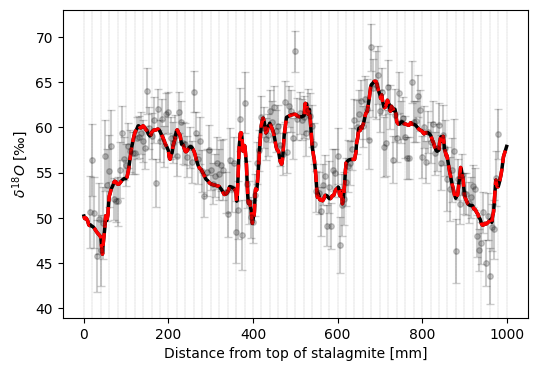

In [9]:
base_path = "../../../../data/"
# echam_path = os.path.join(base_path, "inputdata_250306A/ECHAM5_d18O_Dayu_Cave.xlsx") 

# df = pd.read_excel(echam_path)
# years = df["Year"].to_numpy()
# d18o = df["d18O"].to_numpy()
# d18o_filtered = df["Filtered d18O"].to_numpy()

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(years, d18o, color = "grey", linewidth = 1, label = "ECHAM5-wiso")
# ax.plot(years, d18o_filtered, color = "black", linewidth = 1, label = "ECHAM5-wiso, low-pass filtered")
# ax.legend(loc = "upper right")
# ax.set_xlabel("Year CE")
# ax.set_ylabel(r"$\delta^{18}O$ [‰]")
# plt.savefig("d18o_echam.jpg")
# plt.show()

depths = np.interp(data["d18ort"], model_ages_1[::-1], data["cs"][::-1], right = np.nan, left = np.nan)[::-1]
d18O_actual = np.interp(data["d18od"], depths, data["d18or"][::-1], right = np.nan, left = np.nan) + np.random.normal(loc = 0, scale = data["d18os"], size= len(data["d18od"]))
years_actual = np.interp(data["d18od"], data["cs"], model_ages_1, right = np.nan, left = np.nan)
years_c14_actual = np.interp(data["c14d"],data["cs"], model_ages_1, right = np.nan, left = np.nan)
print(d18O_actual)

fig, ax = plt.subplots(figsize=(6, 4))
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
ax.errorbar(
    data["d18od"], 
    d18O_actual, 
    data["d18os"]*np.ones(len(d18O_actual)), 
    color = "black",
    fmt='o',              # circular markers
    linestyle='none',     # no line between points
    capsize=3,
    markersize = 4,
    alpha = 0.2,
)
ax.plot(depths, data["d18or"][::-1], linewidth = 2.5, color = "black")
ax.plot(depths, data["d18or"][::-1], linewidth = 2.5, color = "red", linestyle = "dashed")
ax.set_xlabel("Distance from top of stalagmite [mm]")
ax.set_ylabel(r"$\delta^{18}O$ $[‰]$")
plt.show()

In [10]:
init_nan = np.full(1, np.nan)
init_nans_c14 = np.full(1 + len(data["c14d"]), np.nan)
extra_nans = np.full(len(data["d18od"]), np.nan)

depths = np.concatenate((np.array([0]), data["c14d"], data["d18od"]))
true_ages = np.concatenate((np.array([data["th"]]), years_c14_actual, years_actual))
cal_c14_ages = np.concatenate((init_nan, data["c14"], extra_nans))
sigma_age = np.concatenate((init_nan, data["c14s"], extra_nans))
d18O = np.concatenate((init_nans_c14, d18O_actual))
sigma_d18O = np.concatenate((init_nans_c14, data["d18os"]))

df = pd.DataFrame({
    "depth": depths,
    "true_age": true_ages,
    "age": cal_c14_ages,
    "sigma_age": sigma_age,
    "d18O": d18O,
    "sigma_d18O": sigma_d18O
}) if not data["dn"] == "biw" else pd.DataFrame({
    "depth": depths,
    "true_age": true_ages,
    "age": cal_c14_ages,
    "sigma_age": sigma_age,
    "inc": d18O,
    "sigma_inc": sigma_d18O
})

df.to_csv(
    os.path.join(base_path, name_map[data["dn"]], "data.txt"),
    sep="\t",
    index=False
)

np.save(f"{base_path}/{name_map[data["dn"]]}/true_sample.npy", samples_1)
#Maybe still something weird here

<function matplotlib.pyplot.show(close=None, block=None)>

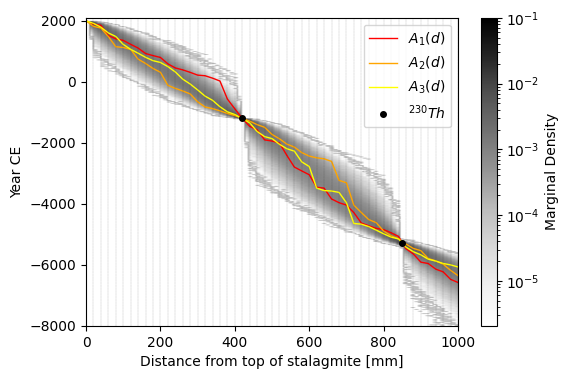

In [8]:
# flat_samples = samples.reshape(-1, samples.shape[-1])
# cumulative_sums = np.cumsum(flat_samples, axis=1) * data["dc"]
# zeros = np.zeros((*flat_samples.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# model_ages = data["th"] - age_offsets

chain = 4
X = samples[chain].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 10
t_edges = np.arange(-8000, 2100 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 10
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")

ax.plot(
    data["cs"],
    model_ages_1,
    color='red',
    alpha=1,
    linewidth=1,
    label = r"$A_1(d)$"
)

ax.plot(
    data["cs"],
    model_ages_2,
    color='orange',
    alpha=1,
    linewidth=1,
    label = r"$A_2(d)$"
)

ax.plot(
    data["cs"],
    model_ages_3,
    color='yellow',
    alpha=1,
    linewidth=1,
    label = r"$A_3(d)$"
)

for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
    

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(-8000, 2100)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/ad_samples.jpg")
plt.show


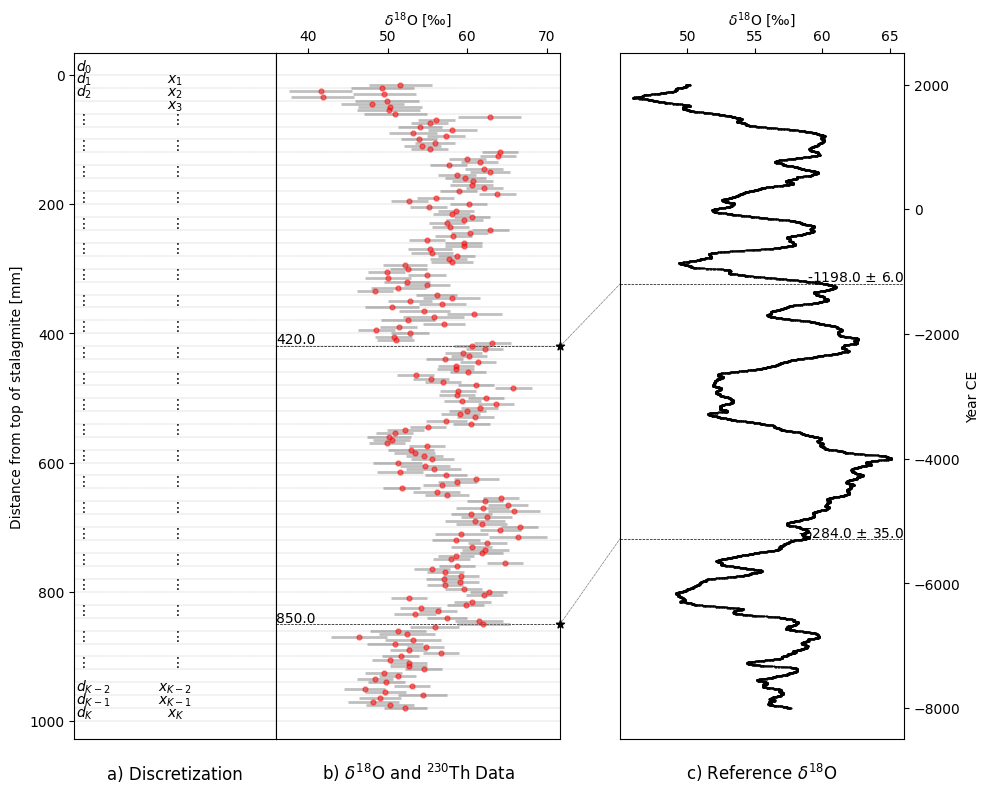

In [7]:
import matplotlib.transforms as mtransforms
from matplotlib.patches import ConnectionPatch

fig, (ax1, ax2, ax3) = plt.subplots(
    ncols=3,
    figsize=(10, 8),
    gridspec_kw={'width_ratios': [1, 2, 2]},
    sharey=False
)

ax1.sharey(ax2)

ax2.errorbar(
    d18O_actual, data["d18od"],
    xerr=data["d18os"],
    fmt='.',                # circle markers
    markersize=7,
    capsize=4,               # small caps on error bars
    elinewidth=2,          # thin error bar lines
    capthick=0,
    color='red',
    ecolor='gray',           # error bar color
    alpha=0.5,
    label="Measurements ± uncertainty"
)
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')
ax2.set_xlabel("$\\delta^{18}$O [‰]")
ax1.invert_yaxis()

extra_depths = data["c14d"]

ax2.scatter(
    [1]*len(extra_depths),   # x-position (right edge)
    extra_depths,
    marker='*',
    color='black',
    transform=ax2.get_yaxis_transform(),
    clip_on=False
)

for i, d in enumerate(data["c14d"]):
    ax2.axhline(y=d, color='k', linestyle='--', linewidth = 0.5, zorder=0)
    # ax1.axhline(y=d, color='r', linestyle='--', linewidth = 0.5, zorder=0)
    if i == len(data["c14"]) - 1:
        y = d + 2
    else:
        y = d
    ax2.text(
        x=ax2.get_xlim()[0] + 0.01,    # right end of x-axis
        y=y ,             # slightly above the line     
        s=f"{d}",          # text
        ha='left',            # align text to the right
        va='bottom',           # bottom of text at y + offset
        # fontsize=8
    )


ax3.plot(data["d18or"], data["d18ort"], color = "k", linewidth = 0.8)
ax3.plot(data["d18or"], data["d18ort"], '.', color = "k", markersize = 1)
# for i in range(config["nch"]):
#     variables = resampled_samples[i,:,:]
#     for j in range(len(variables)):
#         d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
#         plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

# plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
ax3.set_ylabel("Year CE")
ax3.set_xlabel("$\\delta^{18}$O [‰]")
ax3.xaxis.tick_top()
ax3.xaxis.set_label_position('top')

# Move y-axis to the right
ax3.yaxis.tick_right()                # Move tick marks to the right
ax3.yaxis.set_label_position("right") # Move y-axis label to the right
ax3.spines['right'].set_position(('outward', 0))  # Position the right spine

for i, d in enumerate(data["c14"]):
    ax3.axhline(y=d, color='k', linestyle='--', linewidth = 0.5, zorder=0)
    # ax1.axhline(y=d, color='r', linestyle='--', linewidth = 0.5, zorder=0)
    if i == len(data["c14"]) - 1:
        y = d - 25
    else:
        y = d
    ax3.text(
        x=ax3.get_xlim()[1] - 0.01,    # right end of x-axis
        y=y,             # slightly above the line     
        s=f"{d} $\\pm$ {data["c14s"][i]}",          # text
        ha='right',            # align text to the right
        va='bottom',           # bottom of text at y + offset
        # fontsize=8
    )

ax1.xaxis.set_visible(False)
ax1.set_ylabel("Distance from top of stalagmite [mm]")

for i, d in enumerate(data["cs"]):
    ax1.axhline(y=d, color='k', linestyle='--', linewidth = 0.1)
    ax2.axhline(y=d, color='k', linestyle='--', linewidth = 0.1)
    if (i>0 and i <=3):
            ax1.text(
                x=ax1.get_xlim()[0] + 0.5,    # center of x-axis
                y=d ,             # slightly above the line
                s=f"$x_{{{i}}}$",          # text
                ha='center',            # align text to the right
                va='bottom',           # bottom of text at y + offset
                # fontsize=8
            )

            ax1.text(
                x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
                y=data["cs"][i-1] ,             # slightly above the line
                s=f"$d_{{{i-1}}}$",          # text
                ha='left',            # align text to the right
                va='bottom',           # bottom of text at y + offset
                # fontsize=8
            )
    elif (i > data["N"] - 3 and i < data["N"]):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$x_{{K-{data["N"] - i}}}$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
        )
            
        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=data["cs"][i] ,             # slightly above the line
            s=f"$d_{{K-{data["N"] - i}}}$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )# fontsize=8
    elif (i == data["N"]):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$x_K$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=data["cs"][i] ,             # slightly above the line
            s=f"$d_K$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )# fontsize=8
    elif (i % 2 == 0 and i != 0):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$\\vdots$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$\\vdots$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

plt.tight_layout(rect = [0, 0.05, 1, 1])
ax2.tick_params(axis='y', left=False, labelleft=False)
pos2 = ax2.get_position()
pos1 = ax1.get_position()
ax1.set_position([pos1.x0, pos2.y0, pos2.x0 - pos1.x0, pos2.height])

for i, d in enumerate(data["c14d"]):
    # Create a line connecting (xlim_max of ax2, depth) to (xlim_min of ax3, depth)
    con = ConnectionPatch(
        xyA=(ax2.get_xlim()[1], d), # Point in ax2 (right side)
        xyB=(ax3.get_xlim()[0], data["c14"][i]), # Point in ax3 (left side)
        coordsA="data", coordsB="data",
        axesA=ax2, axesB=ax3,
        color="black", linestyle="--", linewidth=0.5, alpha=0.5
    )
    fig.add_artist(con)

ax1.set_title("a) Discretization", y=-0.07)
ax2.set_title("b) $\\delta^{18}$O and $^{230}$Th Data", y=-0.07)
ax3.set_title("c) Reference $\\delta^{18}$O", y=-0.07)
plt.savefig(f"{output_dir}/fancy_fig_classic_new.jpg")
plt.show()

